# Random Forest — Baseline
Treino em 2020–2023, teste em 2024. Sem SMOTE — desbalanceamento tratado via `class_weight='balanced'`.
Random Forest não lida com NaN nativamente — imputa-se antes do classificador.
Métricas prioritárias: **Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1**

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.metrics import (
    precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

BASE_DIR     = '../../data/features/baseline'
OUTPUT_MOD   = '../../output/modelos'
OUTPUT_MET   = '../../output/metricas'
ALGO         = 'random_forest'
DATASET      = 'baseline'
RANDOM_STATE = 42
YEAR_COL     = 'year'

## 1. Carregamento dos dados

In [2]:
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

mask    = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

print(f'X_train: {X_train.shape} | Óbitos: {int(y_train.sum()):,} ({y_train.mean()*100:.2f}%)')
print(f'X_test:  {X_test.shape}  | Óbitos: {int(y_test.sum()):,} ({y_test.mean()*100:.2f}%)')

X_train: (137743, 52) | Óbitos: 2,640 (1.92%)
X_test:  (160534, 52)  | Óbitos: 5,295 (3.30%)


## 2. Pipeline
Random Forest não aceita NaN — imputa-se mediana para contínuas e moda para binárias.

In [3]:
ALRM_COLS = [c for c in X_train.columns if c.startswith('ALRM_')]
GRAV_COLS = [c for c in X_train.columns if c.startswith('GRAV_')]
SYMP_COLS = [
    'FEBRE','MIALGIA','CEFALEIA','EXANTEMA','VOMITO','NAUSEA',
    'DOR_COSTAS','CONJUNTVIT','ARTRITE','ARTRALGIA','PETEQUIA_N',
    'LEUCOPENIA','LACO','DOR_RETRO','DIABETES','HEMATOLOG',
    'HEPATOPAT','RENAL','HIPERTENSA','AUTO_IMUNE',
]
SYMP_COLS = [c for c in SYMP_COLS if c in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        # Ausência informativa: NaN → 0
        ('alrm_grav',
         SimpleImputer(strategy='constant', fill_value=0),
         ALRM_COLS + GRAV_COLS),

        # Sintomas binários: NaN → moda
        ('sintomas',
         SimpleImputer(strategy='most_frequent'),
         SYMP_COLS),

        # Contínuas com ordem natural: mediana
        ('continuas',
         SimpleImputer(strategy='median'),
         ['age_years', 'epi_week']),

        # CS_SEXO: encode ordinal F→0/M→1 → moda
        ('sexo',
         Pipeline([
             ('enc', OrdinalEncoder(categories=[['F', 'M']],
                                    handle_unknown='use_encoded_value',
                                    unknown_value=np.nan)),
             ('imp', SimpleImputer(strategy='most_frequent')),
         ]),
         ['CS_SEXO']),

        # CS_ESCOL_N: ordinal com ordem natural (0=sem escolaridade … 7=superior completo)
        ('escol',
         SimpleImputer(strategy='median'),
         ['CS_ESCOL_N']),

        # CS_RACA: categórica nominal — one-hot (sem ordem entre raças)
        ('raca',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         ['CS_RACA']),

        # CS_GESTANT: categórica com categorias especiais — one-hot
        ('gestant',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         ['CS_GESTANT']),

        # SG_UF: encode ordinal
        ('uf',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         ['SG_UF']),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

print('Pipeline definido.')

Pipeline definido.


## 3. Treinamento

In [4]:
def prep_X(df):
    df = df.copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df.drop(columns=[YEAR_COL], errors='ignore')

X_train_prep = prep_X(X_train)
X_test_prep  = prep_X(X_test)

pipeline.fit(X_train_prep, y_train)
print('Treinamento concluído.')

Treinamento concluído.


## 4. Avaliação

=== Random Forest — Baseline (2020–2023 → 2024) ===
  sensibilidade: 0.624
  especificidade: 0.9831
  auprc: 0.6276
  roc_auc: 0.9209
  f1: 0.5884
  precisao: 0.5567
  threshold: 0.5
  n_train: 137743
  n_obito_train: 2640

              precision    recall  f1-score   support

        Cura       0.99      0.98      0.99    155239
       Óbito       0.56      0.62      0.59      5295

    accuracy                           0.97    160534
   macro avg       0.77      0.80      0.79    160534
weighted avg       0.97      0.97      0.97    160534



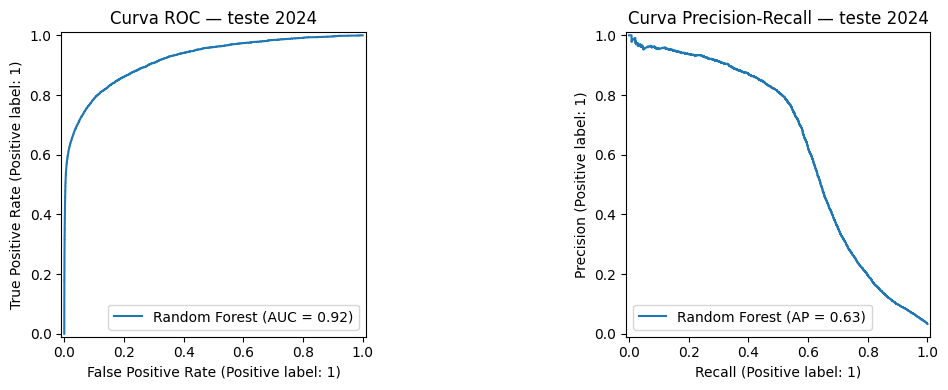

In [5]:
y_te  = y_test.dropna()
proba = pipeline.predict_proba(X_test_prep)[:, 1]
proba = proba[y_test.notna().values]

def calcular_metricas(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'auprc':          round(average_precision_score(y_true, y_pred_proba), 4),
        'roc_auc':        round(roc_auc_score(y_true, y_pred_proba), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'precisao':       round(precision_score(y_true, y_pred, zero_division=0), 4),
        'threshold':      threshold,
        'n_train':        len(X_train_prep),
        'n_obito_train':  int(y_train.sum()),
    }

metricas = calcular_metricas(y_te, proba)
print('=== Random Forest — Baseline (2020–2023 → 2024) ===')
for k, v in metricas.items():
    print(f'  {k}: {v}')

print()
print(classification_report(y_te, (proba >= 0.5).astype(int), target_names=['Cura', 'Óbito']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba, ax=axes[0], name='Random Forest')
axes[0].set_title('Curva ROC — teste 2024')
PrecisionRecallDisplay.from_predictions(y_te, proba, ax=axes[1], name='Random Forest')
axes[1].set_title('Curva Precision-Recall — teste 2024')
plt.tight_layout()
plt.show()

## 5. Matriz de Confusão (threshold = 0.5)

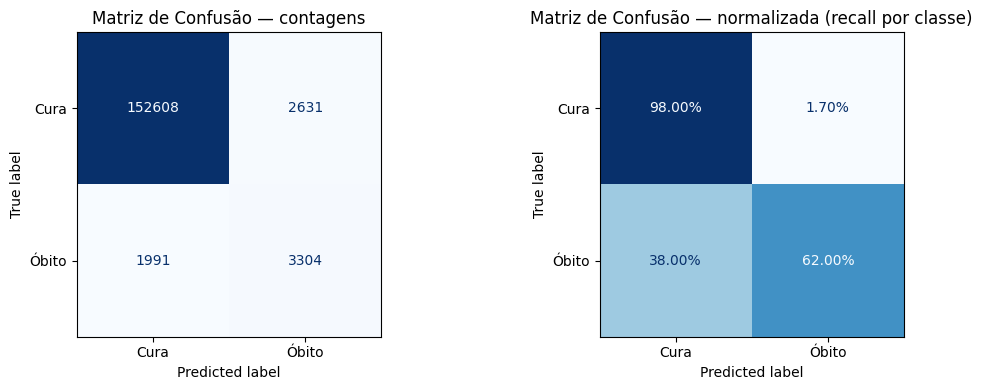

VP (óbitos detectados):   3,304
FN (óbitos perdidos):     1,991
FP (falsos alarmes):      2,631
VN (curas classificadas): 152,608


In [6]:
y_pred_05      = (proba >= 0.5).astype(int)
cm             = confusion_matrix(y_te, y_pred_05)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(cm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — contagens')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — normalizada (recall por classe)')
for text in axes[1].texts:
    text.set_text(f'{float(text.get_text()):.2%}')

plt.tight_layout()
plt.show()

print(f'VP (óbitos detectados):   {tp:,}')
print(f'FN (óbitos perdidos):     {fn:,}')
print(f'FP (falsos alarmes):      {fp:,}')
print(f'VN (curas classificadas): {tn:,}')

## 6. Análise de threshold

Threshold padrão  (0.50): sens=0.6240 | esp=0.9831
Threshold Youden  (0.25): sens=0.7802 | esp=0.9061
Threshold sens≥90% (0.10): sens=0.9041 | esp=0.7108


,threshold,sensibilidade,especificidade,precisao,f1,tp,fp,fn,tn
0,0.05,0.9586,0.5165,0.0633,0.1188,5076,75052,219,80187
1,0.10,0.9041,0.7108,0.0964,0.1742,4787,44890,508,110349
2,0.15,0.8561,0.8097,0.1330,0.2303,4533,29546,762,125693
3,0.20,0.8166,0.8673,0.1735,0.2862,4324,20598,971,134641
4,0.25,0.7802,0.9061,0.2208,0.3442,4131,14577,1164,140662
5,0.30,0.7422,0.9336,0.2760,0.4023,3930,10311,1365,144928
6,0.35,0.7061,0.9533,0.3404,0.4594,3739,7245,1556,147994
7,0.40,0.6755,0.9674,0.4143,0.5136,3577,5056,1718,150183
8,0.45,0.6457,0.9770,0.4895,0.5568,3419,3566,1876,151673
9,0.50,0.6240,0.9831,0.5567,0.5884,3304,2631,1991,152608


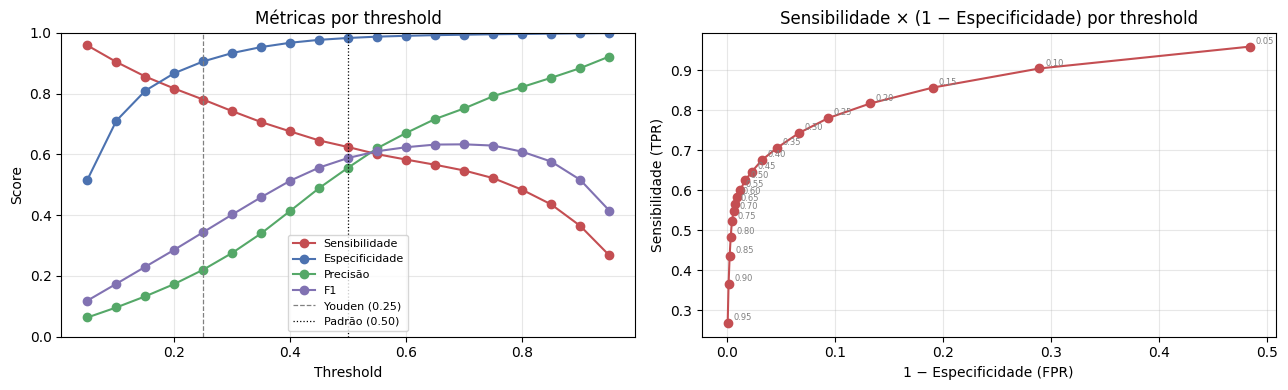

In [7]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []

for t in thresholds:
    y_pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    rows.append({
        'threshold':      round(t, 2),
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'precisao':       round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
        'f1':             round(f1_score(y_te, y_pred), 4),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    })

df_thresh = pd.DataFrame(rows)
df_thresh['youden'] = df_thresh['sensibilidade'] + df_thresh['especificidade'] - 1
idx_youden = df_thresh['youden'].idxmax()

high_sens = df_thresh[df_thresh['sensibilidade'] >= 0.90]
idx_90    = high_sens['especificidade'].idxmax() if not high_sens.empty else None

print(f"Threshold padrão  (0.50): sens={df_thresh.loc[df_thresh['threshold']==0.50, 'sensibilidade'].values[0]:.4f} "
      f"| esp={df_thresh.loc[df_thresh['threshold']==0.50, 'especificidade'].values[0]:.4f}")
print(f"Threshold Youden  ({df_thresh.loc[idx_youden,'threshold']:.2f}): "
      f"sens={df_thresh.loc[idx_youden,'sensibilidade']:.4f} | esp={df_thresh.loc[idx_youden,'especificidade']:.4f}")
if idx_90 is not None:
    print(f"Threshold sens≥90% ({df_thresh.loc[idx_90,'threshold']:.2f}): "
          f"sens={df_thresh.loc[idx_90,'sensibilidade']:.4f} | esp={df_thresh.loc[idx_90,'especificidade']:.4f}")

display(df_thresh.drop(columns='youden'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_thresh['threshold'], df_thresh['sensibilidade'], 'o-', color='#C44E52', label='Sensibilidade')
axes[0].plot(df_thresh['threshold'], df_thresh['especificidade'], 'o-', color='#4C72B0', label='Especificidade')
axes[0].plot(df_thresh['threshold'], df_thresh['precisao'],       'o-', color='#55A868', label='Precisão')
axes[0].plot(df_thresh['threshold'], df_thresh['f1'],             'o-', color='#8172B2', label='F1')
axes[0].axvline(df_thresh.loc[idx_youden, 'threshold'], color='gray', linestyle='--',
                linewidth=0.9, label=f'Youden ({df_thresh.loc[idx_youden,"threshold"]:.2f})')
axes[0].axvline(0.5, color='black', linestyle=':', linewidth=0.9, label='Padrão (0.50)')
axes[0].set_title('Métricas por threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(1 - df_thresh['especificidade'], df_thresh['sensibilidade'], 'o-', color='#C44E52')
for _, row in df_thresh.iterrows():
    axes[1].annotate(f"{row['threshold']:.2f}",
                     (1 - row['especificidade'], row['sensibilidade']),
                     textcoords='offset points', xytext=(4, 2), fontsize=6, color='gray')
axes[1].set_title('Sensibilidade × (1 − Especificidade) por threshold')
axes[1].set_xlabel('1 − Especificidade (FPR)')
axes[1].set_ylabel('Sensibilidade (TPR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Importância das features

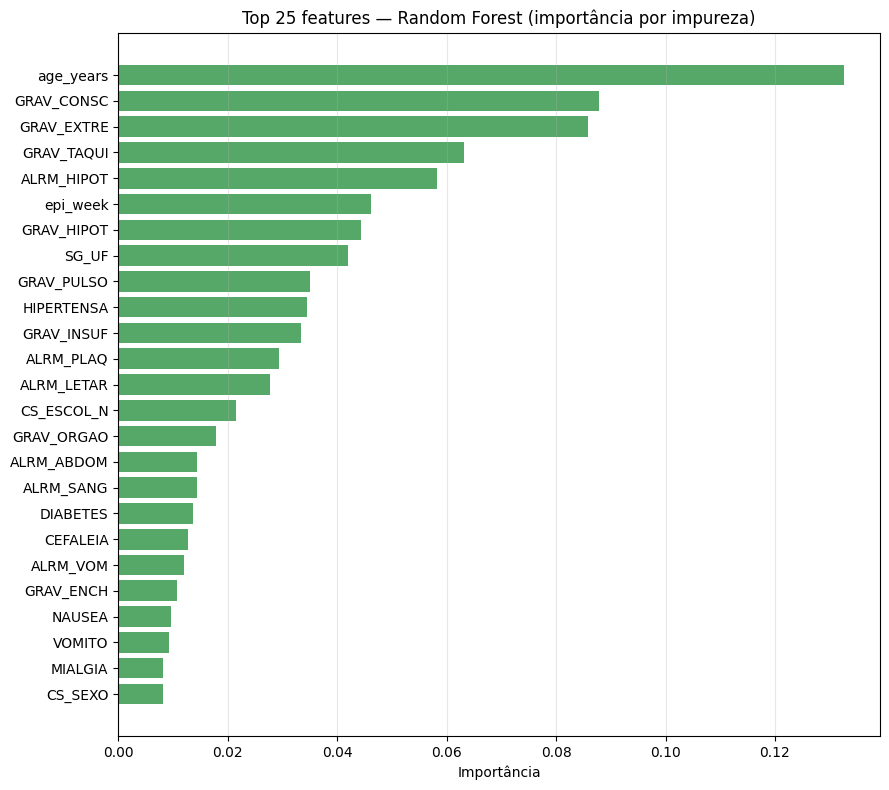

,feature,importance
44,age_years,0.132560
22,GRAV_CONSC,0.087752
14,GRAV_EXTRE,0.085846
13,GRAV_TAQUI,0.063197
0,ALRM_HIPOT,0.058195
45,epi_week,0.046228
15,GRAV_HIPOT,0.044336
59,SG_UF,0.042056
9,GRAV_PULSO,0.035110
42,HIPERTENSA,0.034550


In [8]:
feature_names = pipeline['pre'].get_feature_names_out()
importances   = pipeline['clf'].feature_importances_

df_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
df_imp = df_imp.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top_n  = 25
df_top = df_imp.head(top_n)
ax.barh(df_top['feature'][::-1], df_top['importance'][::-1], color='#55A868')
ax.set_title(f'Top {top_n} features — Random Forest (importância por impureza)')
ax.set_xlabel('Importância')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

display(df_imp.head(15))

## 8. Salvamento

In [9]:
os.makedirs(OUTPUT_MOD, exist_ok=True)
os.makedirs(OUTPUT_MET, exist_ok=True)

model_path = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET}.joblib')
joblib.dump(pipeline, model_path)
print(f'Modelo salvo: {model_path}')

df_met = pd.DataFrame([metricas])
df_met['label']   = f'{ALGO}_{DATASET}'
df_met['dataset'] = DATASET
met_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}.parquet')
df_met.to_parquet(met_path, index=False)
print(f'Métricas salvas: {met_path}')

df_pred = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba})
pred_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}_predicoes.parquet')
df_pred.to_parquet(pred_path, index=False)
print(f'Predições salvas: {pred_path}')

Modelo salvo: ../../output/modelos/random_forest_baseline.joblib
Métricas salvas: ../../output/metricas/random_forest_baseline.parquet
Predições salvas: ../../output/metricas/random_forest_baseline_predicoes.parquet


## 9. Otimização de Hiperparâmetros (GridSearchCV)
Busca exaustiva sobre `max_depth`, `min_samples_leaf` e `max_features`. `n_estimators` fixo em 300.
Avaliação por `StratifiedKFold(5)` dentro do train set (2020–2023). Scoring: `average_precision` (AUPRC).

Total: 2 × 3 × 2 = 12 combinações × 5 folds = 60 fits.

In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def build_pipeline():
    return Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

param_grid = {
    'clf__max_depth':        [None, 20],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__max_features':     ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=build_pipeline(),
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train_prep, y_train)

print(f'\nMelhores parâmetros: {grid_search.best_params_}')
print(f'Melhor AUPRC (CV):   {grid_search.best_score_:.4f}')

df_cv = pd.DataFrame(grid_search.cv_results_)
df_cv = df_cv[['param_clf__max_depth', 'param_clf__min_samples_leaf', 'param_clf__max_features',
               'mean_test_score', 'std_test_score', 'rank_test_score']]
df_cv = df_cv.sort_values('rank_test_score')
display(df_cv)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Melhores parâmetros: {'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1}
Melhor AUPRC (CV):   0.6537


,param_clf__max_depth,param_clf__min_samples_leaf,param_clf__max_features,mean_test_score,std_test_score,rank_test_score
3,None,1,log2,0.653713,0.016083,1
0,None,1,sqrt,0.653244,0.017617,2
4,None,5,log2,0.646308,0.022219,3
1,None,5,sqrt,0.645742,0.021110,4
10,20,5,log2,0.642312,0.022483,5
5,None,10,log2,0.641216,0.021969,6
7,20,5,sqrt,0.639983,0.022138,7
2,None,10,sqrt,0.639738,0.020423,8
11,20,10,log2,0.639463,0.021857,9
8,20,10,sqrt,0.636832,0.019524,10


## 10. Avaliação — Modelo Tunado

=== Comparação: Baseline vs Tunado ===
Métrica              Baseline     Tunado
----------------------------------------
sensibilidade          0.6240     0.4457  (-0.1783)
especificidade         0.9831     0.9974  (+0.0143)
auprc                  0.6276     0.6268  (-0.0008)
roc_auc                0.9209     0.9038  (-0.0171)
f1                     0.5884     0.5859  (-0.0025)


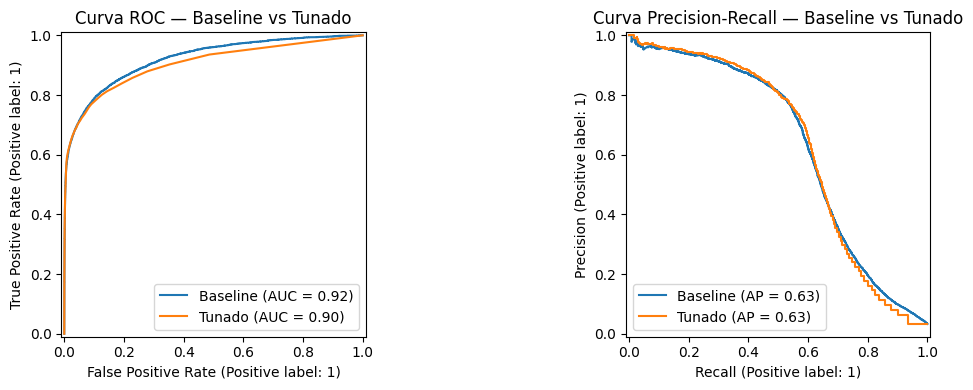

In [11]:
pipeline_tuned = grid_search.best_estimator_

proba_tuned = pipeline_tuned.predict_proba(X_test_prep)[:, 1]
proba_tuned = proba_tuned[y_test.notna().values]

metricas_tuned = calcular_metricas(y_te, proba_tuned)

print('=== Comparação: Baseline vs Tunado ===')
print(f"{'Métrica':<18} {'Baseline':>10} {'Tunado':>10}")
print('-' * 40)
for k in ['sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1']:
    v_base  = metricas[k]
    v_tuned = metricas_tuned[k]
    diff    = v_tuned - v_base
    sinal   = '+' if diff >= 0 else ''
    print(f'{k:<18} {v_base:>10.4f} {v_tuned:>10.4f}  ({sinal}{diff:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba,       ax=axes[0], name='Baseline')
RocCurveDisplay.from_predictions(y_te, proba_tuned, ax=axes[0], name='Tunado')
axes[0].set_title('Curva ROC — Baseline vs Tunado')

PrecisionRecallDisplay.from_predictions(y_te, proba,       ax=axes[1], name='Baseline')
PrecisionRecallDisplay.from_predictions(y_te, proba_tuned, ax=axes[1], name='Tunado')
axes[1].set_title('Curva Precision-Recall — Baseline vs Tunado')
plt.tight_layout()
plt.show()

## 11. Salvamento — Modelo Tunado

In [12]:
DATASET_TUNED = f'{DATASET}_tuned'

model_path_tuned = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET_TUNED}.joblib')
joblib.dump(pipeline_tuned, model_path_tuned)
print(f'Modelo salvo: {model_path_tuned}')

df_met_tuned = pd.DataFrame([metricas_tuned])
df_met_tuned['label']       = f'{ALGO}_{DATASET_TUNED}'
df_met_tuned['dataset']     = DATASET_TUNED
df_met_tuned['best_params'] = str(grid_search.best_params_)
met_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}.parquet')
df_met_tuned.to_parquet(met_path_tuned, index=False)
print(f'Métricas salvas: {met_path_tuned}')

df_pred_tuned = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba_tuned})
pred_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}_predicoes.parquet')
df_pred_tuned.to_parquet(pred_path_tuned, index=False)
print(f'Predições salvas: {pred_path_tuned}')

Modelo salvo: ../../output/modelos/random_forest_baseline_tuned.joblib
Métricas salvas: ../../output/metricas/random_forest_baseline_tuned.parquet
Predições salvas: ../../output/metricas/random_forest_baseline_tuned_predicoes.parquet


## 12. Conclusão

O Random Forest **não superou** a regressão logística nas métricas prioritárias do projeto.

| Modelo               | Sensibilidade | Especificidade | AUPRC      | ROC-AUC    |
|----------------------|--------------|----------------|------------|------------|
| Logística (baseline) | **0.8004**   | 0.8853         | 0.6250     | **0.9242** |
| XGBoost (baseline)   | 0.7490       | 0.9098         | 0.6112     | 0.9098     |
| LightGBM (baseline)  | 0.6820       | 0.9520         | 0.6098     | 0.9024     |
| Random Forest        | 0.6240       | **0.9831**     | **0.6276** | 0.9209     |

**Observações:**
- O Random Forest apresenta a menor sensibilidade (0.6240) entre todos os modelos — o padrão de árvores privilegiando especificidade é ainda mais acentuado que no LightGBM.
- AUPRC levemente superior à logística (0.6276 vs 0.6250) indica capacidade de ranking marginalmente melhor, mas ao custo de sensibilidade muito inferior no threshold padrão.
- Ajuste de threshold para ≥0.20 recupera sensibilidade (~0.80), mas gera ~17k falsos alarmes contra ~7k da logística em threshold=0.50.

**Modelo selecionado até o momento:** `logistic_regression_baseline`.